## Conditional Volatility Models: No-BoE-Intervention Counterfactual

This notebook estimates the conditional volatility of daily changes in the Bank of England 10-year nominal zero-coupon gilt yield using information available **through 27 September 2022**.

The same conditional-volatility families used in Notebook 05 are considered:

- ARCH
- GARCH
- EGARCH
- GJR-GARCH
- TARCH

The information set is frozen on **27 September 2022**.

From **28 September 2022 onward**:

- the conditional-mean model is not updated;
- the conditional-volatility models are not updated;
- no post-intervention observation is fed back into either model;
- all volatility paths are fixed-origin forecasts.

Actual observations after 28 September are used only for ex-post comparison and forecast evaluation.

This is a **model-based no-BoE-intervention volatility counterfactual**, not a causal estimate of the Bank of England intervention.

### Install and import packages

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("arch") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "arch"
    ])

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from arch import arch_model

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)

### Load the processed BoE dataset

In [3]:
DATA_PATH = (
    Path("data")
    / "processed"
    / "boe_10y_zero_coupon_clean.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run Notebook 01 first so that "
        "data/processed/boe_10y_zero_coupon_clean.csv is created."
    )

boe = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

required_columns = {
    "date",
    "yield_10y"
}

if not required_columns.issubset(
    boe.columns
):
    raise ValueError(
        f"Expected columns {required_columns}, "
        f"but found {set(boe.columns)}"
    )

boe = (
    boe
    .sort_values("date")
    .drop_duplicates(
        subset="date",
        keep="first"
    )
    .reset_index(drop=True)
)

boe["yield_10y"] = pd.to_numeric(
    boe["yield_10y"],
    errors="coerce"
)

boe = (
    boe
    .dropna(
        subset=[
            "date",
            "yield_10y"
        ]
    )
    .reset_index(drop=True)
)

print(f"Loaded: {DATA_PATH}")
print(f"Observations: {len(boe)}")
print(
    "Date range:",
    boe["date"].min().date(),
    "to",
    boe["date"].max().date()
)

boe.head()

Loaded: data/processed/boe_10y_zero_coupon_clean.csv
Observations: 2779
Date range: 2014-01-02 to 2024-12-31


,date,yield_10y,date_raw,yield_raw
0,2014-01-02,3.1625,02 Jan 14,3.1625
1,2014-01-03,3.1579,03 Jan 14,3.1579
2,2014-01-06,3.1053,06 Jan 14,3.1053
3,2014-01-07,3.0831,07 Jan 14,3.0831
4,2014-01-08,3.1140,08 Jan 14,3.1140


### Create the modelling series

Daily changes are measured in basis points:

$$
\Delta y_t^{bps} =
100(y_t-y_{t-1}).
$$

The conditional-volatility models are fitted to innovations/errors measured in basis points.

In [4]:
model_data = (
    boe[
        [
            "date",
            "yield_10y"
        ]
    ]
    .copy()
)

model_data["yield_change"] = (
    model_data["yield_10y"]
    .diff()
)

model_data["yield_change_bps"] = (
    model_data["yield_change"]
    * 100
)

model_data.head()

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09


### Define the no-BoE-intervention information set

The final observation allowed into the models is **27 September 2022**.

The counterfactual forecast begins on **28 September 2022**, the date of the Bank of England intervention.

The default forecast window ends on **14 October 2022**, the final day of the temporary gilt-purchase programme.

In [5]:
INTERVENTION_DATE = pd.Timestamp(
    "2022-09-28"
)

INFO_CUTOFF = pd.Timestamp(
    "2022-09-27"
)

COUNTERFACTUAL_END = pd.Timestamp(
    "2022-10-14"
)

information_set = (
    model_data.loc[
        model_data["date"] <= INFO_CUTOFF
    ]
    .copy()
    .reset_index(drop=True)
)

counterfactual_window = (
    model_data.loc[
        (
            model_data["date"]
            >= INTERVENTION_DATE
        )
        &
        (
            model_data["date"]
            <= COUNTERFACTUAL_END
        )
    ]
    .copy()
    .reset_index(drop=True)
)

if information_set.empty:
    raise ValueError(
        "Information set is empty."
    )

if counterfactual_window.empty:
    raise ValueError(
        "Counterfactual window is empty."
    )

if (
    information_set["date"].max()
    != INFO_CUTOFF
):
    raise ValueError(
        "The final information-set observation "
        "is not 27 September 2022."
    )

if (
    counterfactual_window["date"].min()
    != INTERVENTION_DATE
):
    raise ValueError(
        "The counterfactual forecast does not begin "
        "on 28 September 2022."
    )

print(
    "Information set:",
    information_set["date"].min().date(),
    "to",
    information_set["date"].max().date()
)

print(
    "Counterfactual window:",
    counterfactual_window["date"].min().date(),
    "to",
    counterfactual_window["date"].max().date()
)

print(
    "Information-set observations:",
    len(information_set)
)

print(
    "Counterfactual observations:",
    len(counterfactual_window)
)

Information set: 2014-01-02 to 2022-09-27
Counterfactual window: 2022-09-28 to 2022-10-14
Information-set observations: 2208
Counterfactual observations: 13


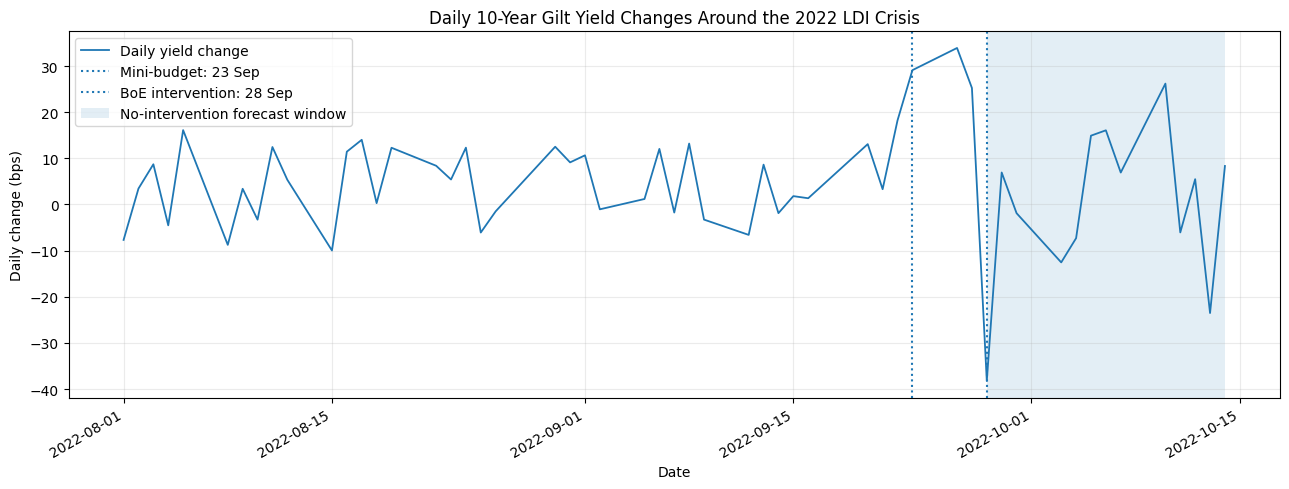

In [6]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

plot_window = (
    model_data.loc[
        model_data["date"].between(
            pd.Timestamp("2022-08-01"),
            COUNTERFACTUAL_END
        )
    ]
    .copy()
)

ax.plot(
    plot_window["date"],
    plot_window["yield_change_bps"],
    linewidth=1.3,
    label="Daily yield change"
)

ax.axvline(
    pd.Timestamp("2022-09-23"),
    linestyle=":",
    linewidth=1.5,
    label="Mini-budget: 23 Sep"
)

ax.axvline(
    INTERVENTION_DATE,
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.axvspan(
    INTERVENTION_DATE,
    COUNTERFACTUAL_END,
    alpha=0.12,
    label="No-intervention forecast window"
)

ax.set_title(
    "Daily 10-Year Gilt Yield Changes Around the 2022 LDI Crisis"
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily change (bps)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Common conditional-mean specification

A common **AR(2)** conditional mean is used for all volatility models so that differences between models arise from the conditional-variance specification.

For daily changes $x_t$,

$$
x_t =
c+\phi_1x_{t-1}+\phi_2x_{t-2}+\varepsilon_t.
$$

The ARCH-family models are fitted to the AR(2) innovations $\varepsilon_t$.

In [7]:
MEAN_AR_ORDER = 2

def fit_mean_model(change_series):

    change_series = (
        pd.Series(change_series)
        .dropna()
        .astype(float)
    )

    fit = SARIMAX(
        change_series,
        order=(
            MEAN_AR_ORDER,
            0,
            0
        ),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(
        disp=False
    )

    residuals = (
        pd.Series(
            np.asarray(
                fit.resid,
                dtype=float
            ),
            index=change_series.index
        )
        .iloc[MEAN_AR_ORDER:]
        .dropna()
    )

    return fit, residuals


information_changes = (
    information_set[
        "yield_change_bps"
    ]
    .dropna()
    .astype(float)
)

mean_fit, innovations = (
    fit_mean_model(
        information_changes
    )
)

print(
    mean_fit.summary()
)

                               SARIMAX Results                                
Dep. Variable:       yield_change_bps   No. Observations:                 2207
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -6645.947
Date:                Sun, 30 Aug 2026   AIC                          13299.895
Time:                        09:06:00   BIC                          13322.689
Sample:                             0   HQIC                         13308.223
                               - 2207                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0594      0.108      0.553      0.580      -0.151       0.270
ar.L1          0.0148      0.013      1.099      0.272      -0.012       0.041
ar.L2          0.0045      0.015      0.307      0.7

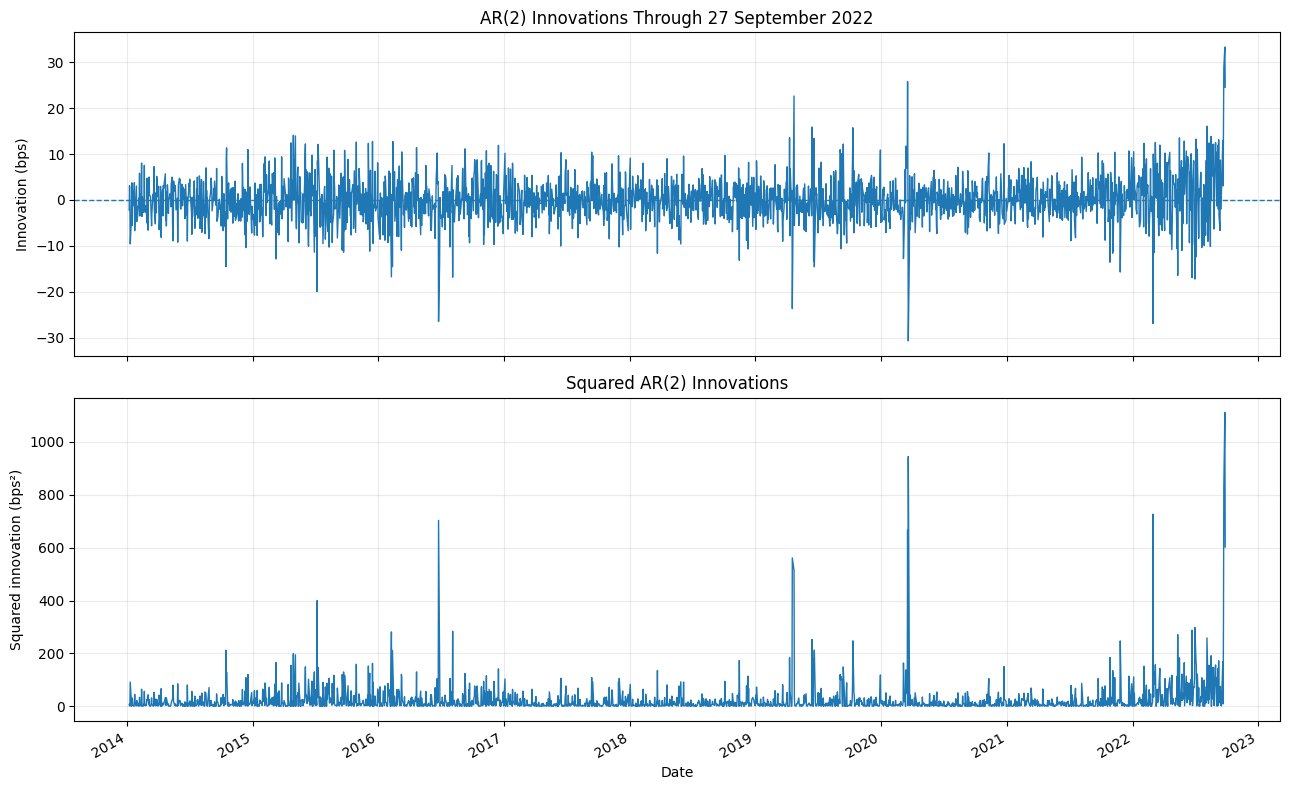

In [8]:
innovation_dates = (
    information_set.loc[
        innovations.index,
        "date"
    ]
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 8)
)

axes[0].plot(
    innovation_dates,
    innovations,
    linewidth=1
)

axes[0].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "AR(2) Innovations Through 27 September 2022"
)

axes[0].set_ylabel(
    "Innovation (bps)"
)

axes[0].grid(
    alpha=0.25
)

axes[1].plot(
    innovation_dates,
    innovations.pow(2),
    linewidth=1
)

axes[1].set_title(
    "Squared AR(2) Innovations"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Squared innovation (bps²)"
)

axes[1].grid(
    alpha=0.25
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The AR(2) conditional-mean model is re-estimated using all available information through **27 September 2022**, including the first three crisis observations. The AR coefficients are small and statistically insignificant $p=0.272$ and $p=0.759$, indicating little remaining short-run predictability in the mean of daily gilt-yield changes.

The errors remain centred around zero, but their magnitude varies substantially over time. This is visible near the end of the sample, where several unusually large innovations occur during 2022. The squared innovations make this more apparent, showing periods of clustered large shocks and a particularly large spike immediately before the 28 September intervention.

The Ljung–Box result at lag 1 $p=0.99$ provides no evidence of first-order autocorrelation in the innovations, while the Jarque–Bera test strongly rejects Gaussian normality and the kurtosis of **7.13** indicates heavy tails. The significant heteroskedasticity statistic also suggests non-constant variance, although the formal test for ARCH effects is carried out separately using the ARCH-LM test.

### Test for ARCH effects

The Engle ARCH-LM test is applied to the AR(2) innovations using only observations available through 27 September 2022.

The ACF of squared innovations is also examined.

In [9]:
ARCH_LM_LAGS = [
    5,
    10,
    20
]

arch_lm_rows = []

for nlags in ARCH_LM_LAGS:

    lm_stat, lm_pvalue, f_stat, f_pvalue = (
        het_arch(
            innovations,
            nlags=nlags
        )
    )

    arch_lm_rows.append({
        "lags": nlags,
        "LM statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F statistic": f_stat,
        "F p-value": f_pvalue
    })

arch_lm_results = pd.DataFrame(
    arch_lm_rows
)

arch_lm_results

,lags,LM statistic,LM p-value,F statistic,F p-value
0,5,327.644129,1.134682e-68,76.785747,2.358639e-74
1,10,331.850424,2.815573e-65,38.899793,5.856834e-71
2,20,337.567570,1.614336e-59,19.770580,4.239425e-65


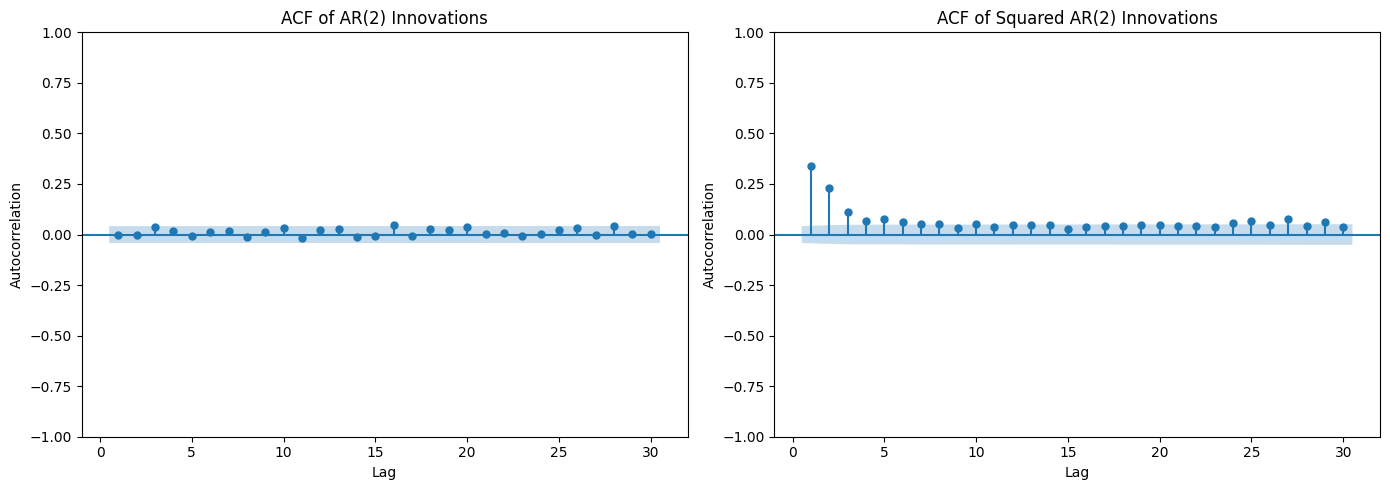

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

plot_acf(
    innovations,
    lags=30,
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "ACF of AR(2) Innovations"
)

axes[0].set_xlabel(
    "Lag"
)

axes[0].set_ylabel(
    "Autocorrelation"
)

plot_acf(
    innovations.pow(2),
    lags=30,
    zero=False,
    ax=axes[1]
)

axes[1].set_title(
    "ACF of Squared AR(2) Innovations"
)

axes[1].set_xlabel(
    "Lag"
)

axes[1].set_ylabel(
    "Autocorrelation"
)

plt.tight_layout()
plt.show()

The ARCH-LM test strongly rejects the null hypothesis of no ARCH effects at lags 5, 10 and 20, with p-values effectively equal to zero. This confirms substantial conditional heteroskedasticity in the AR(2) innovations and supports fitting ARCH-family volatility models.

The ACF of the AR(2) errors is close to zero across most lags, indicating little remaining linear autocorrelation in the conditional mean.

In contrast, the squared innovations show clear positive autocorrelation, especially at the first few lags, confirming volatility clustering and supporting the ARCH-LM evidence of conditional heteroskedasticity.

### Select the ARCH order

ARCH orders from 1 to 10 are compared using AIC and BIC using only the information available through 27 September 2022.

A common hold-back is used so that the competing ARCH specifications are compared using the same effective sample.

In [11]:
DIST = "t"

ARCH_MAX_P = 10

COMMON_HOLD_BACK = (
    ARCH_MAX_P
)

arch_order_rows = []

for p in range(
    1,
    ARCH_MAX_P + 1
):

    try:

        model = arch_model(
            innovations,
            mean="Zero",
            vol="ARCH",
            p=p,
            dist=DIST,
            hold_back=COMMON_HOLD_BACK,
            rescale=False
        )

        fit = model.fit(
            disp="off",
            show_warning=False
        )

        arch_order_rows.append({
            "p": p,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "loglikelihood": fit.loglikelihood,
            "convergence_flag": fit.convergence_flag
        })

    except Exception:

        arch_order_rows.append({
            "p": p,
            "AIC": np.nan,
            "BIC": np.nan,
            "loglikelihood": np.nan,
            "convergence_flag": np.nan
        })


arch_order_selection = (
    pd.DataFrame(
        arch_order_rows
    )
    .dropna(
        subset=["AIC"]
    )
    .sort_values(
        [
            "AIC",
            "BIC"
        ]
    )
    .reset_index(
        drop=True
    )
)

best_arch_p = int(
    arch_order_selection.loc[
        0,
        "p"
    ]
)

print(
    "Selected ARCH order by AIC:",
    f"ARCH({best_arch_p})"
)

arch_order_selection

Selected ARCH order by AIC: ARCH(7)


,p,AIC,BIC,loglikelihood,convergence_flag
0,7,12874.008993,12925.254429,-6428.004496,0
1,8,12874.773395,12931.712768,-6427.386697,0
2,6,12875.827333,12921.378832,-6429.913666,0
3,9,12876.142909,12938.776220,-6427.071455,0
4,10,12877.807827,12946.135075,-6426.903913,0
5,5,12888.339706,12928.197267,-6437.169853,0
6,4,12892.594227,12926.757851,-6440.297113,0
7,3,12897.325152,12925.794839,-6443.662576,0
8,2,12916.842976,12939.618725,-6454.421488,0
9,1,12947.397201,12964.479013,-6470.698600,0


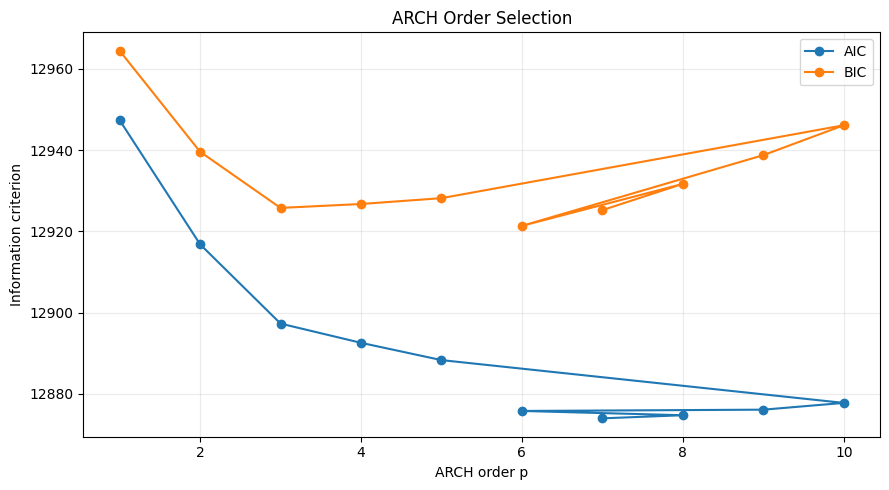

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    arch_order_selection["p"],
    arch_order_selection["AIC"],
    marker="o",
    label="AIC"
)

ax.plot(
    arch_order_selection["p"],
    arch_order_selection["BIC"],
    marker="o",
    label="BIC"
)

ax.set_title(
    "ARCH Order Selection"
)

ax.set_xlabel(
    "ARCH order p"
)

ax.set_ylabel(
    "Information criterion"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

AIC selects **ARCH(7)** with the lowest AIC value of **12874.01**, while BIC prefers the more parsimonious ARCH(6).  

Because AIC is being used as the primary selection criterion in this notebook, **ARCH(7) is retained**. The nearby AIC values for ARCH(6)–ARCH(8) also suggest that the exact higher-order choice is not sharply separated.

### Define the conditional-volatility models

The candidate models are:

- ARCH(\(p\))
- GARCH(1,1)
- EGARCH(1,1,1)
- GJR-GARCH(1,1,1)
- TARCH(1,1,1)

All models use Student-\(t\) conditional errors.

GJR-GARCH uses a squared-shock asymmetry term. TARCH uses absolute shocks through `power=1.0`.

In [13]:
MODEL_SPECS = {

    f"ARCH({best_arch_p})": {
        "vol": "ARCH",
        "p": best_arch_p
    },

    "GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "power": 2.0
    },

    "EGARCH(1,1,1)": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1
    },

    "GJR-GARCH(1,1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "power": 2.0
    },

    "TARCH(1,1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "power": 1.0
    }
}


def build_volatility_model(
    innovation_series,
    spec,
    hold_back=COMMON_HOLD_BACK
):

    kwargs = {
        "y": (
            pd.Series(
                innovation_series
            )
            .dropna()
            .astype(float)
        ),
        "mean": "Zero",
        "vol": spec["vol"],
        "p": spec["p"],
        "dist": DIST,
        "hold_back": hold_back,
        "rescale": False
    }

    if "o" in spec:
        kwargs["o"] = spec["o"]

    if "q" in spec:
        kwargs["q"] = spec["q"]

    if "power" in spec:
        kwargs["power"] = spec["power"]

    return arch_model(
        **kwargs
    )


def fit_volatility_model(
    innovation_series,
    spec,
    hold_back=COMMON_HOLD_BACK
):

    model = build_volatility_model(
        innovation_series,
        spec,
        hold_back=hold_back
    )

    return model.fit(
        disp="off",
        show_warning=False
    )

### Fit the five volatility models through 27 September 2022

In [14]:
volatility_fits = {}

for name, spec in (
    MODEL_SPECS.items()
):

    volatility_fits[name] = (
        fit_volatility_model(
            innovations,
            spec
        )
    )


fit_comparison = pd.DataFrame([
    {
        "model": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "loglikelihood": fit.loglikelihood,
        "convergence_flag": fit.convergence_flag
    }

    for name, fit in (
        volatility_fits.items()
    )
]).sort_values(
    [
        "AIC",
        "BIC"
    ]
).reset_index(
    drop=True
)

fit_comparison

,model,AIC,BIC,loglikelihood,convergence_flag
0,"TARCH(1,1,1)",12855.650288,12884.119974,-6422.825144,0
1,"EGARCH(1,1,1)",12855.790403,12884.260089,-6422.895201,0
2,"GJR-GARCH(1,1,1)",12857.348716,12885.818402,-6423.674358,0
3,"GARCH(1,1)",12859.327360,12882.103110,-6425.663680,0
4,ARCH(7),12874.008993,12925.254429,-6428.004496,0


- TARCH(1,1,1) has the lowest AIC (**12855.65**), with EGARCH(1,1,1) almost identical (**12855.79**).  
- GARCH(1,1) has the lowest BIC (**12882.10**), reflecting BIC's stronger penalty for model complexity.  
- ARCH(7) performs worst on both AIC and BIC, while all models converged successfully.  

In [15]:
for name, fit in (
    volatility_fits.items()
):

    print(
        "=" * 90
    )

    print(
        name
    )

    print(
        "=" * 90
    )

    print(
        fit.summary()
    )

    print()

ARCH(7)
                           Zero Mean - ARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                             ARCH   Log-Likelihood:               -6428.00
Distribution:      Standardized Student's t   AIC:                           12874.0
Method:                  Maximum Likelihood   BIC:                           12925.3
                                              No. Observations:                 2195
Date:                      Sun, Aug 30 2026   Df Residuals:                     2195
Time:                              09:13:12   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------

In [16]:
parameter_rows = []

for model_name, fit in (
    volatility_fits.items()
):

    for parameter, value in (
        fit.params.items()
    ):

        parameter_rows.append({
            "model": model_name,
            "parameter": parameter,
            "estimate": value
        })


parameter_table = pd.DataFrame(
    parameter_rows
)

parameter_table

,model,parameter,estimate
0,ARCH(7),omega,10.431104
1,ARCH(7),alpha[1],0.111833
2,ARCH(7),alpha[2],0.121447
3,ARCH(7),alpha[3],0.083708
4,ARCH(7),alpha[4],0.038684
5,ARCH(7),alpha[5],0.061323
6,ARCH(7),alpha[6],0.103857
7,ARCH(7),alpha[7],0.046052
8,ARCH(7),nu,8.442385
9,"GARCH(1,1)",omega,1.001118


The GARCH-family models show very high **volatility persistence**, with large $\beta_1$ estimates, particularly EGARCH (**0.993**) and TARCH (**0.949**). 

The asymmetry parameters $\gamma_1$ in EGARCH, GJR-GARCH and TARCH are not statistically significant at the 5% level, so there is little evidence of asymmetric responses to positive and negative shocks.

The Student-\(t\) degrees of freedom are around **7–8** across all models, supporting the use of a heavy-tailed distribution.  

### Fitted conditional volatility through 27 September

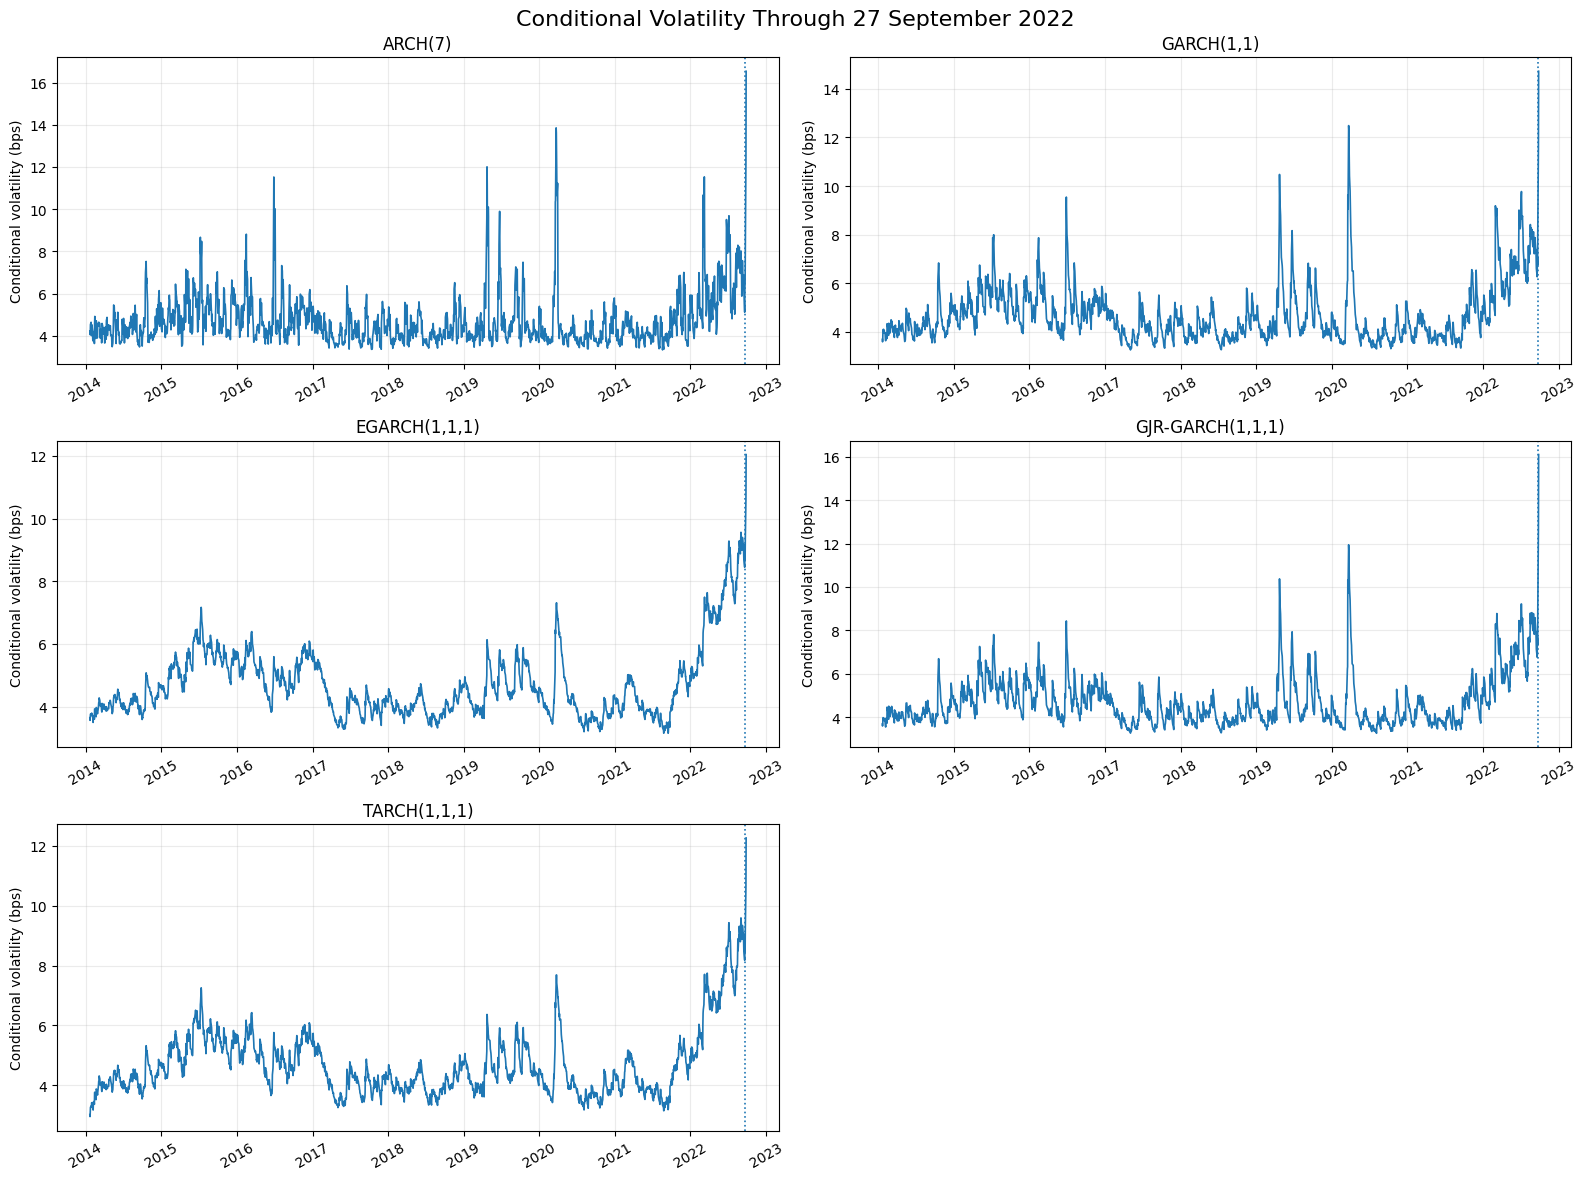

In [17]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (name, fit) in zip(
    axes[:5],
    volatility_fits.items()
):

    sigma = (
        pd.Series(
            fit.conditional_volatility
        )
        .dropna()
    )

    dates = (
        information_set.loc[
            sigma.index,
            "date"
        ]
    )

    ax.plot(
        dates,
        sigma,
        linewidth=1.2
    )

    ax.axvline(
        pd.Timestamp("2022-09-23"),
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(
        name
    )

    ax.set_ylabel(
        "Conditional volatility (bps)"
    )

    ax.grid(
        alpha=0.25
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis(
    "off"
)

plt.suptitle(
    "Conditional Volatility Through 27 September 2022",
    fontsize=16
)

plt.tight_layout()
plt.show()

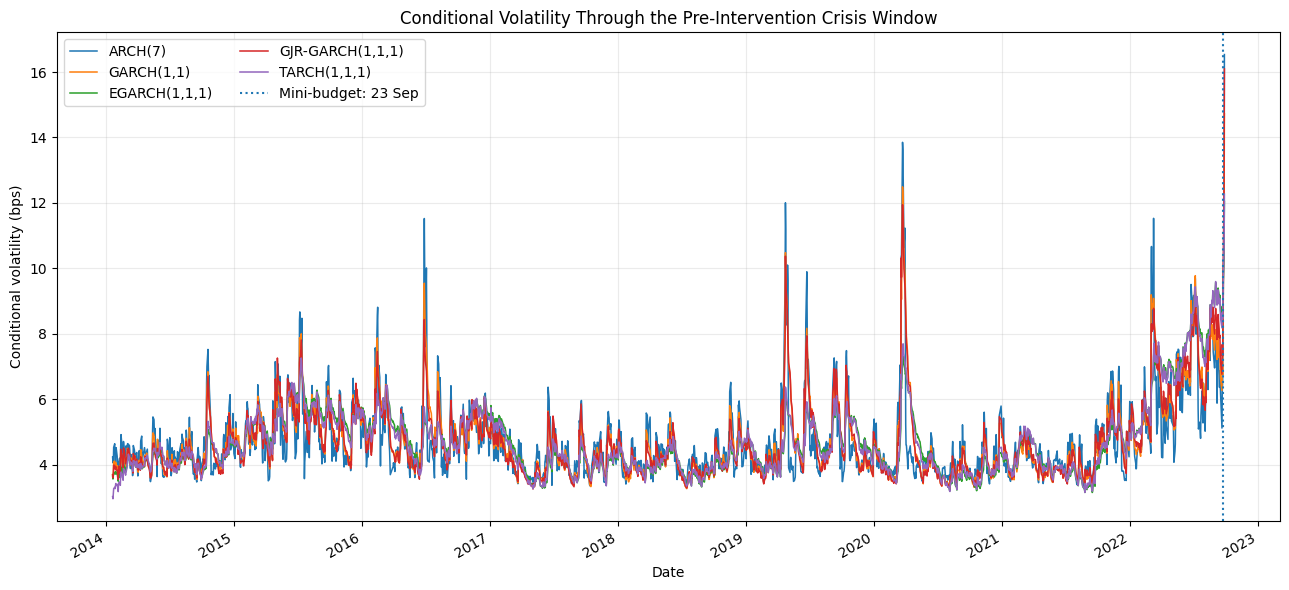

In [19]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for name, fit in (
    volatility_fits.items()
):

    sigma = (
        pd.Series(
            fit.conditional_volatility
        )
        .dropna()
    )

    dates = (
        information_set.loc[
            sigma.index,
            "date"
        ]
    )

    ax.plot(
        dates,
        sigma,
        linewidth=1.1,
        label=name
    )

ax.axvline(
    pd.Timestamp("2022-09-23"),
    linestyle=":",
    linewidth=1.5,
    label="Mini-budget: 23 Sep"
)

ax.set_title(
    "Conditional Volatility Through the Pre-Intervention Crisis Window"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Conditional volatility (bps)"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    ncol=2
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

All five models identify broadly the same volatility episodes and show a clear rise in conditional volatility during 2022.

ARCH(7) reacts more sharply to individual shocks, while GARCH, EGARCH, GJR-GARCH and TARCH produce smoother and more persistent paths.

By 23–27 September, all models indicate substantially elevated volatility relative to much of the earlier sample, showing that market stress had already increased before the BoE intervention.

### Volatility-model residual diagnostics

Diagnostics are computed using only the information available through 27 September 2022.

The following are reported:

- Ljung-Box tests on standardised residuals;
- Ljung-Box tests on squared standardised residuals;
- ARCH-LM test on standardised residuals;
- Jarque-Bera distributional diagnostic.

In [20]:
def safe_lb_pvalue(
    series,
    lag
):

    series = (
        pd.Series(series)
        .dropna()
    )

    if len(series) <= lag + 5:
        return np.nan

    result = acorr_ljungbox(
        series,
        lags=[lag],
        return_df=True
    )

    return float(
        result[
            "lb_pvalue"
        ].iloc[-1]
    )


diagnostic_rows = []

for name, fit in (
    volatility_fits.items()
):

    std_resid = (
        pd.Series(
            fit.std_resid
        )
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
    )

    std_resid_sq = (
        std_resid.pow(2)
    )

    lm_stat, lm_p, _, _ = (
        het_arch(
            std_resid,
            nlags=10
        )
    )

    jb = jarque_bera(
        std_resid
    )

    diagnostic_rows.append({
        "model": name,

        "LB resid p (10)":
            safe_lb_pvalue(
                std_resid,
                10
            ),

        "LB resid p (20)":
            safe_lb_pvalue(
                std_resid,
                20
            ),

        "LB squared resid p (10)":
            safe_lb_pvalue(
                std_resid_sq,
                10
            ),

        "LB squared resid p (20)":
            safe_lb_pvalue(
                std_resid_sq,
                20
            ),

        "ARCH-LM p (10)":
            lm_p,

        "Jarque-Bera statistic":
            jb.statistic,

        "Jarque-Bera p":
            jb.pvalue
    })


volatility_diagnostics = (
    pd.DataFrame(
        diagnostic_rows
    )
)

volatility_diagnostics

,model,LB resid p (10),LB resid p (20),LB squared resid p (10),LB squared resid p (20),ARCH-LM p (10),Jarque-Bera statistic,Jarque-Bera p
0,ARCH(7),0.726564,0.560003,9.929013e-01,9.980422e-01,9.929209e-01,258.574767,7.099091e-57
1,"GARCH(1,1)",0.763590,0.590613,6.114626e-01,9.035282e-01,5.983985e-01,254.510568,5.416670e-56
2,"EGARCH(1,1,1)",0.505129,0.423618,1.205457e-09,1.088541e-07,7.884240e-08,418.481236,1.342623e-91
3,"GJR-GARCH(1,1,1)",0.680617,0.518360,5.997094e-01,8.749734e-01,5.926298e-01,230.785590,7.683268e-51
4,"TARCH(1,1,1)",0.506094,0.406051,1.222133e-07,6.406252e-06,2.197336e-06,377.641864,9.910858e-83


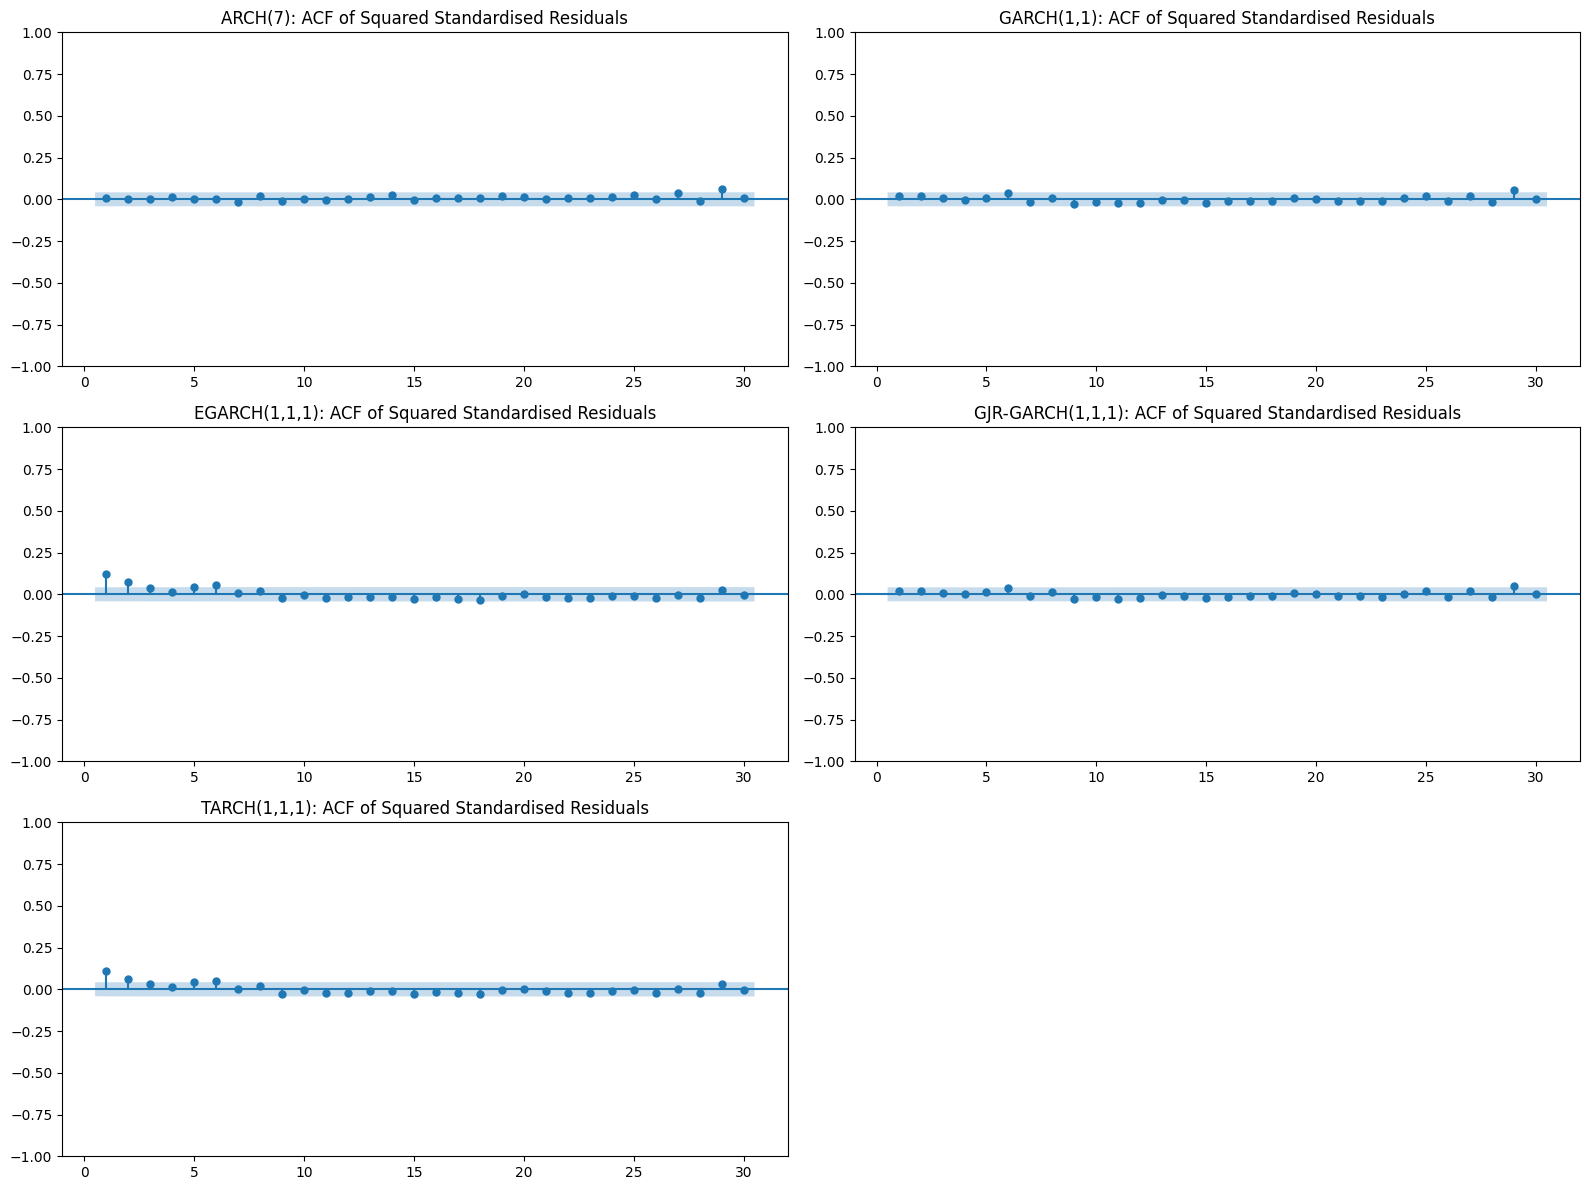

In [21]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (name, fit) in zip(
    axes[:5],
    volatility_fits.items()
):

    std_resid = (
        pd.Series(
            fit.std_resid
        )
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
    )

    plot_acf(
        std_resid.pow(2),
        lags=30,
        zero=False,
        ax=ax
    )

    ax.set_title(
        f"{name}: ACF of Squared Standardised Residuals"
    )

axes[5].axis(
    "off"
)

plt.tight_layout()
plt.show()

ARCH(7), GARCH(1,1) and GJR-GARCH(1,1,1) show no significant residual autocorrelation or remaining ARCH effects, indicating that they capture the conditional-variance structure well.

In contrast, EGARCH and TARCH retain significant autocorrelation in squared standardised residuals and strongly reject the ARCH-LM null, so some volatility dependence remains unexplained.

Jarque–Bera rejects Gaussian normality for all models, but this is not unexpected because the models use a Student-\(t\) distribution rather than assuming normal innovations.

### Fixed-origin volatility forecast functions

Simulation forecasts are used for all five model families so that ARCH, GARCH, EGARCH, GJR-GARCH and TARCH are forecast on the same basis over the full intervention window.

In [22]:
EPS = 1e-10

N_SIMULATIONS = 5000


def simulated_variance_forecast(
    fit,
    horizon,
    simulations=5000,
    seed=42
):

    np.random.seed(
        seed
    )

    forecast = fit.forecast(
        horizon=horizon,
        method="simulation",
        simulations=simulations,
        reindex=False
    )

    variance = (
        forecast.variance
        .iloc[-1]
        .to_numpy(
            dtype=float
        )
    )

    return np.maximum(
        variance,
        EPS
    )


def volatility_metrics(
    realized_innovation,
    forecast_variance
):

    realized_innovation = np.asarray(
        realized_innovation,
        dtype=float
    )

    forecast_variance = np.asarray(
        forecast_variance,
        dtype=float
    )

    realized_sq = (
        realized_innovation ** 2
    )

    forecast_variance = np.maximum(
        forecast_variance,
        EPS
    )

    qlike = np.mean(
        np.log(
            forecast_variance
        )
        +
        realized_sq
        / forecast_variance
    )

    variance_error = (
        forecast_variance
        - realized_sq
    )

    realized_abs = np.abs(
        realized_innovation
    )

    forecast_sigma = np.sqrt(
        forecast_variance
    )

    sigma_error = (
        forecast_sigma
        - realized_abs
    )

    return {

        "QLIKE":
            qlike,

        "Variance MAE (bps²)":
            np.mean(
                np.abs(
                    variance_error
                )
            ),

        "Variance RMSE (bps²)":
            np.sqrt(
                np.mean(
                    variance_error ** 2
                )
            ),

        "Volatility MAE (bps)":
            np.mean(
                np.abs(
                    sigma_error
                )
            ),

        "Volatility RMSE (bps)":
            np.sqrt(
                np.mean(
                    sigma_error ** 2
                )
            )
    }

### No-BoE-intervention volatility counterfactual

In [23]:
CF_HORIZON = len(
    counterfactual_window
)

no_intervention_mean_forecast = (
    mean_fit
    .get_forecast(
        steps=CF_HORIZON
    )
    .predicted_mean
)

no_intervention_mean_forecast = np.asarray(
    no_intervention_mean_forecast,
    dtype=float
)

no_intervention_variance_forecasts = {}

for i, (name, fit) in enumerate(
    volatility_fits.items()
):

    no_intervention_variance_forecasts[
        name
    ] = simulated_variance_forecast(
        fit,
        horizon=CF_HORIZON,
        simulations=N_SIMULATIONS,
        seed=SEED + 100 + i
    )


no_intervention_table = (
    counterfactual_window[
        [
            "date",
            "yield_10y",
            "yield_change_bps"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

no_intervention_table = (
    no_intervention_table.rename(
        columns={
            "yield_10y":
                "actual_yield_percent",

            "yield_change_bps":
                "actual_change_bps"
        }
    )
)

no_intervention_table[
    "fixed_AR2_mean_forecast_change_bps"
] = no_intervention_mean_forecast

no_intervention_table[
    "realized_innovation_bps"
] = (
    no_intervention_table[
        "actual_change_bps"
    ]
    -
    no_intervention_table[
        "fixed_AR2_mean_forecast_change_bps"
    ]
)

no_intervention_table[
    "realized_abs_innovation_bps"
] = (
    no_intervention_table[
        "realized_innovation_bps"
    ]
    .abs()
)

no_intervention_table[
    "realized_squared_innovation_bps2"
] = (
    no_intervention_table[
        "realized_innovation_bps"
    ] ** 2
)


for name, variance in (
    no_intervention_variance_forecasts.items()
):

    no_intervention_table[
        f"{name} variance forecast"
    ] = variance

    no_intervention_table[
        f"{name} sigma forecast"
    ] = np.sqrt(
        variance
    )


no_intervention_table

,date,actual_yield_percent,actual_change_bps,fixed_AR2_mean_forecast_change_bps,realized_innovation_bps,realized_abs_innovation_bps,realized_squared_innovation_bps2,ARCH(7) variance forecast,ARCH(7) sigma forecast,"GARCH(1,1) variance forecast","GARCH(1,1) sigma forecast","EGARCH(1,1,1) variance forecast","EGARCH(1,1,1) sigma forecast","GJR-GARCH(1,1,1) variance forecast","GJR-GARCH(1,1,1) sigma forecast","TARCH(1,1,1) variance forecast","TARCH(1,1,1) sigma forecast"
0,2022-09-28,4.0517,-38.24,0.586913,-38.826913,38.826913,1507.529178,312.777317,17.685512,243.189182,15.594524,166.561256,12.905861,291.672184,17.078413,175.738743,13.256649
1,2022-09-29,4.1210,6.93,0.182905,6.747095,6.747095,45.523286,269.167017,16.406310,234.787641,15.322782,164.670371,12.832395,280.080235,16.735598,173.236975,13.161952
2,2022-09-30,4.1021,-1.89,0.064810,-1.954810,1.954810,3.821283,252.770932,15.898771,225.280584,15.009350,162.859174,12.761629,269.337140,16.411494,170.922917,13.073749
3,2022-10-03,3.9766,-12.55,0.061226,-12.611226,12.611226,159.043031,287.651286,16.960286,217.067787,14.733221,160.924328,12.685595,259.443405,16.107247,168.401737,12.976969
4,2022-10-04,3.9036,-7.30,0.060636,-7.360636,7.360636,54.178967,297.857638,17.258553,208.950436,14.455118,159.208491,12.617785,249.634213,15.799817,165.938521,12.881713
5,2022-10-05,4.0527,14.91,0.060611,14.849389,14.849389,220.504345,240.793332,15.517517,202.552356,14.232089,157.541157,12.551540,240.638773,15.512536,163.664391,12.793138
6,2022-10-06,4.2134,16.07,0.060608,16.009392,16.009392,256.300625,179.230819,13.387711,195.917053,13.997037,155.646762,12.475847,232.512916,15.248374,161.458702,12.706640
7,2022-10-07,4.2826,6.92,0.060608,6.859392,6.859392,47.051258,150.410209,12.264184,189.441262,13.763766,153.929729,12.406842,223.661490,14.955316,159.250072,12.619432
8,2022-10-10,4.5445,26.19,0.060608,26.129392,26.129392,682.745123,136.899344,11.700399,182.351510,13.503759,152.292353,12.340679,215.607761,14.683588,157.131031,12.535192
9,2022-10-11,4.4839,-6.06,0.060608,-6.120608,6.120608,37.461843,128.292709,11.326637,176.207091,13.274302,150.692175,12.275674,207.363220,14.400112,155.088678,12.453460


- The no-BoE fixed-origin forecasts imply conditional volatility of roughly **13–18 bps on 28 September**, compared with a realised absolute innovation of **38.83 bps**.
- Forecast volatility then declines gradually across all models because post-intervention observations are not fed back into the forecasts.
- Several later shocks, particularly **10 October (26.13 bps)** and **13 October (23.59 bps)**, also exceed the model-implied volatility levels. 

### Plot the no-BoE-intervention conditional-volatility forecasts

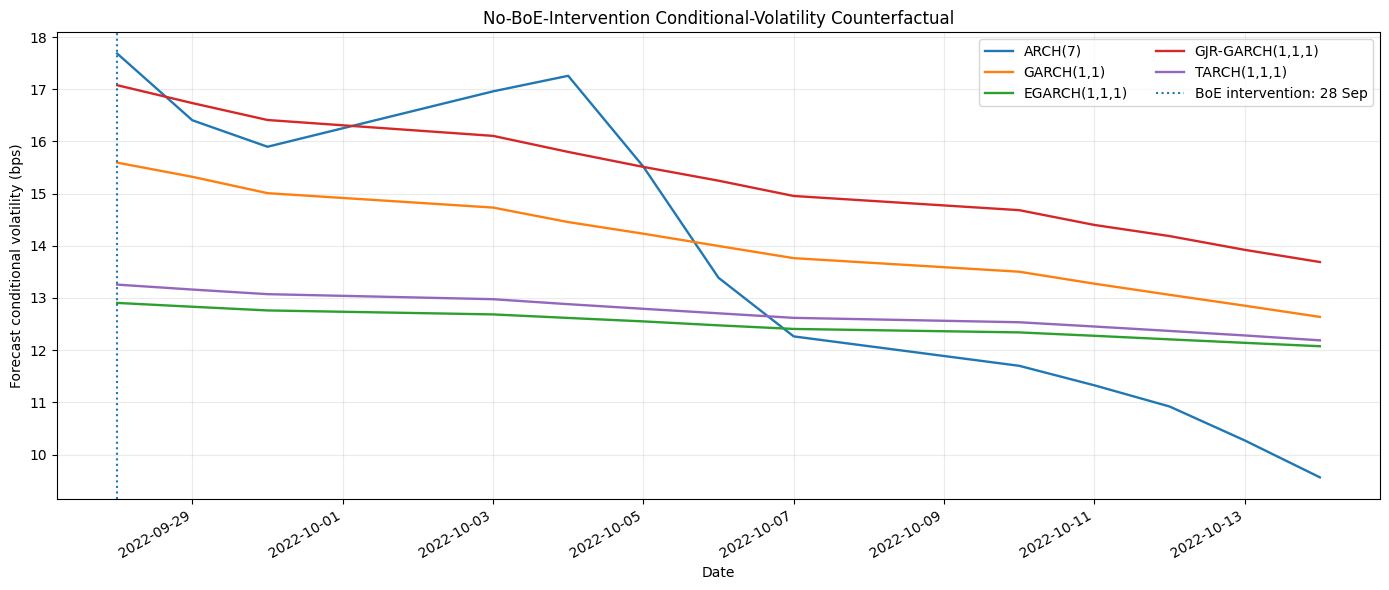

In [24]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

for name in (
    MODEL_SPECS.keys()
):

    ax.plot(
        no_intervention_table["date"],
        no_intervention_table[
            f"{name} sigma forecast"
        ],
        linewidth=1.7,
        label=name
    )

ax.axvline(
    INTERVENTION_DATE,
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.set_title(
    "No-BoE-Intervention Conditional-Volatility Counterfactual"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Forecast conditional volatility (bps)"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    ncol=2
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The no-BoE counterfactual implies elevated conditional volatility immediately after **28 September**, with forecasts ranging from about **13 to 18 bps** across models.

Volatility then generally declines over the forecast horizon because no post-intervention observations are fed back into the models.

ARCH(7) falls most rapidly, while GJR-GARCH and GARCH imply more persistent volatility; EGARCH and TARCH produce lower and smoother paths.

The spread between models shows that the no-intervention volatility baseline is model-dependent, so these paths should be interpreted as statistical counterfactuals rather than causal estimates.

### Compare realised post-intervention shock magnitude with the fixed no-intervention volatility paths

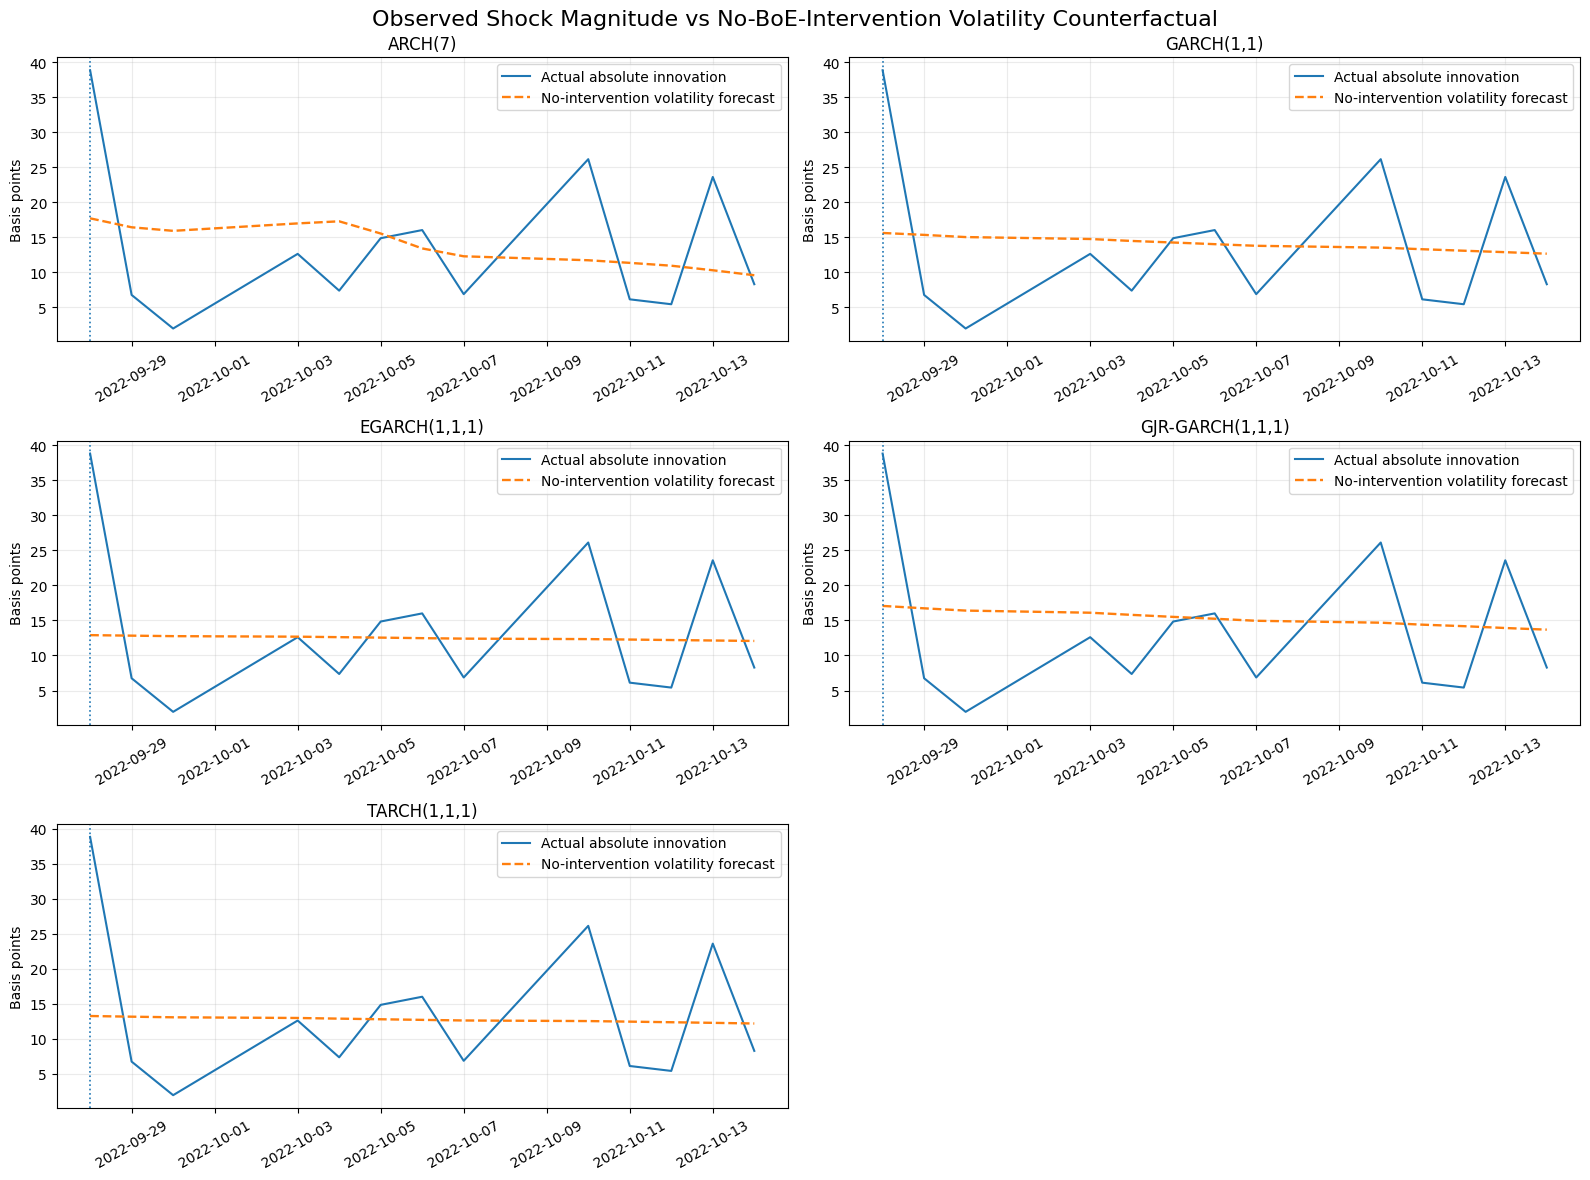

In [25]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, name in zip(
    axes[:5],
    MODEL_SPECS.keys()
):

    ax.plot(
        no_intervention_table["date"],
        no_intervention_table[
            "realized_abs_innovation_bps"
        ],
        linewidth=1.5,
        label="Actual absolute innovation"
    )

    ax.plot(
        no_intervention_table["date"],
        no_intervention_table[
            f"{name} sigma forecast"
        ],
        linestyle="--",
        linewidth=1.7,
        label="No-intervention volatility forecast"
    )

    ax.axvline(
        INTERVENTION_DATE,
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(
        name
    )

    ax.set_ylabel(
        "Basis points"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()

    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis(
    "off"
)

plt.suptitle(
    "Observed Shock Magnitude vs No-BoE-Intervention Volatility Counterfactual",
    fontsize=16
)

plt.tight_layout()
plt.show()

The realised shock on **28 September** is far larger than every no-intervention volatility forecast, at about **38.8 bps** versus roughly **13–18 bps** predicted by the models.

Several later shocks, particularly around **10 and 13 October**, also exceed the counterfactual volatility paths, while many intervening observations fall below them.

The post-intervention period contains repeated realised shocks larger than those implied by the information available through 27 September, although the comparison remains model-dependent and non-causal.

##£. Ex-post forecast evaluation

The post-intervention observations are used only after all fixed-origin forecasts have been generated.

Squared AR(2) forecast innovations are used as the realised-variance proxy.

QLIKE is reported together with variance and volatility-scale MAE/RMSE.

In [26]:
realized_post_intervention_innovations = (
    no_intervention_table[
        "realized_innovation_bps"
    ]
    .to_numpy(
        dtype=float
    )
)

evaluation_rows = []

for name in (
    MODEL_SPECS.keys()
):

    variance = (
        no_intervention_table[
            f"{name} variance forecast"
        ]
        .to_numpy(
            dtype=float
        )
    )

    row = {
        "model": name
    }

    row.update(
        volatility_metrics(
            realized_post_intervention_innovations,
            variance
        )
    )

    evaluation_rows.append(
        row
    )


post_intervention_forecast_metrics = (
    pd.DataFrame(
        evaluation_rows
    )
    .sort_values(
        "QLIKE"
    )
    .reset_index(
        drop=True
    )
)

post_intervention_forecast_metrics

,model,QLIKE,Variance MAE (bps²),Variance RMSE (bps²),Volatility MAE (bps),Volatility RMSE (bps)
0,"GJR-GARCH(1,1,1)",6.613433,270.982268,402.544965,8.555330,10.118230
1,"GARCH(1,1)",6.661261,259.342058,410.067819,8.163910,9.976606
2,ARCH(7),6.738093,264.680863,406.732971,8.263539,10.125153
3,"TARCH(1,1,1)",6.799819,251.087157,423.505570,7.861821,10.053351
4,"EGARCH(1,1,1)",6.833358,249.714016,425.721351,7.807793,10.082360


- GJR-GARCH(1,1,1) achieves the lowest **QLIKE (6.61)**, making it the preferred model under the primary volatility-loss criterion.
- However, no model dominates every metric: EGARCH has the lowest variance and volatility MAE, while GARCH has the lowest volatility RMSE.
- The relatively close QLIKE values indicate that forecast performance is broadly similar across the five specifications.

### Standardise post-intervention innovations by each no-intervention volatility forecast

In [27]:
standardized_innovation_table = (
    no_intervention_table[
        [
            "date",
            "actual_yield_percent",
            "actual_change_bps",
            "fixed_AR2_mean_forecast_change_bps",
            "realized_innovation_bps",
            "realized_abs_innovation_bps"
        ]
    ]
    .copy()
)

for name in (
    MODEL_SPECS.keys()
):

    sigma = (
        no_intervention_table[
            f"{name} sigma forecast"
        ]
    )

    standardized_innovation_table[
        f"{name} standardized innovation"
    ] = (
        no_intervention_table[
            "realized_innovation_bps"
        ]
        / sigma
    )


standardized_innovation_table

,date,actual_yield_percent,actual_change_bps,fixed_AR2_mean_forecast_change_bps,realized_innovation_bps,realized_abs_innovation_bps,ARCH(7) standardized innovation,"GARCH(1,1) standardized innovation","EGARCH(1,1,1) standardized innovation","GJR-GARCH(1,1,1) standardized innovation","TARCH(1,1,1) standardized innovation"
0,2022-09-28,4.0517,-38.24,0.586913,-38.826913,38.826913,-2.195408,-2.489779,-3.008471,-2.273450,-2.928863
1,2022-09-29,4.1210,6.93,0.182905,6.747095,6.747095,0.411250,0.440331,0.525786,0.403158,0.512621
2,2022-09-30,4.1021,-1.89,0.064810,-1.954810,1.954810,-0.122954,-0.130240,-0.153179,-0.119112,-0.149522
3,2022-10-03,3.9766,-12.55,0.061226,-12.611226,12.611226,-0.743574,-0.855972,-0.994138,-0.782954,-0.971816
4,2022-10-04,3.9036,-7.30,0.060636,-7.360636,7.360636,-0.426492,-0.509206,-0.583354,-0.465868,-0.571402
5,2022-10-05,4.0527,14.91,0.060611,14.849389,14.849389,0.956944,1.043374,1.183073,0.957251,1.160731
6,2022-10-06,4.2134,16.07,0.060608,16.009392,16.009392,1.195827,1.143770,1.283231,1.049908,1.259923
7,2022-10-07,4.2826,6.92,0.060608,6.859392,6.859392,0.559303,0.498366,0.552872,0.458659,0.543558
8,2022-10-10,4.5445,26.19,0.060608,26.129392,26.129392,2.233205,1.934972,2.117338,1.779496,2.084483
9,2022-10-11,4.4839,-6.06,0.060608,-6.120608,6.120608,-0.540373,-0.461087,-0.498596,-0.425039,-0.491478


The standardised errors show that several post-intervention observations were large relative to the no-BoE volatility forecasts.

The **28 September** shock is unusual, with standardised errors between about **−2.2 and −3.0** across the models. Large positive and negative shocks also occur on **10 October** and **13 October**, with magnitudes around or above 2 standard deviations for several specifications.

Most other observations lie within roughly ±1.5, indicating that the largest deviations are concentrated on a small number of days.

### Model-based volatility gaps

In [28]:
volatility_gap_table = (
    no_intervention_table[
        [
            "date",
            "realized_abs_innovation_bps"
        ]
    ]
    .copy()
)

for name in (
    MODEL_SPECS.keys()
):

    volatility_gap_table[
        f"{name} gap (bps)"
    ] = (
        no_intervention_table[
            "realized_abs_innovation_bps"
        ]
        -
        no_intervention_table[
            f"{name} sigma forecast"
        ]
    )


volatility_gap_table.round(
    3
)

,date,realized_abs_innovation_bps,ARCH(7) gap (bps),"GARCH(1,1) gap (bps)","EGARCH(1,1,1) gap (bps)","GJR-GARCH(1,1,1) gap (bps)","TARCH(1,1,1) gap (bps)"
0,2022-09-28,38.827,21.141,23.232,25.921,21.749,25.570
1,2022-09-29,6.747,-9.659,-8.576,-6.085,-9.989,-6.415
2,2022-09-30,1.955,-13.944,-13.055,-10.807,-14.457,-11.119
3,2022-10-03,12.611,-4.349,-2.122,-0.074,-3.496,-0.366
4,2022-10-04,7.361,-9.898,-7.094,-5.257,-8.439,-5.521
5,2022-10-05,14.849,-0.668,0.617,2.298,-0.663,2.056
6,2022-10-06,16.009,2.622,2.012,3.534,0.761,3.303
7,2022-10-07,6.859,-5.405,-6.904,-5.547,-8.096,-5.760
8,2022-10-10,26.129,14.429,12.626,13.789,11.446,13.594
9,2022-10-11,6.121,-5.206,-7.154,-6.155,-8.280,-6.333


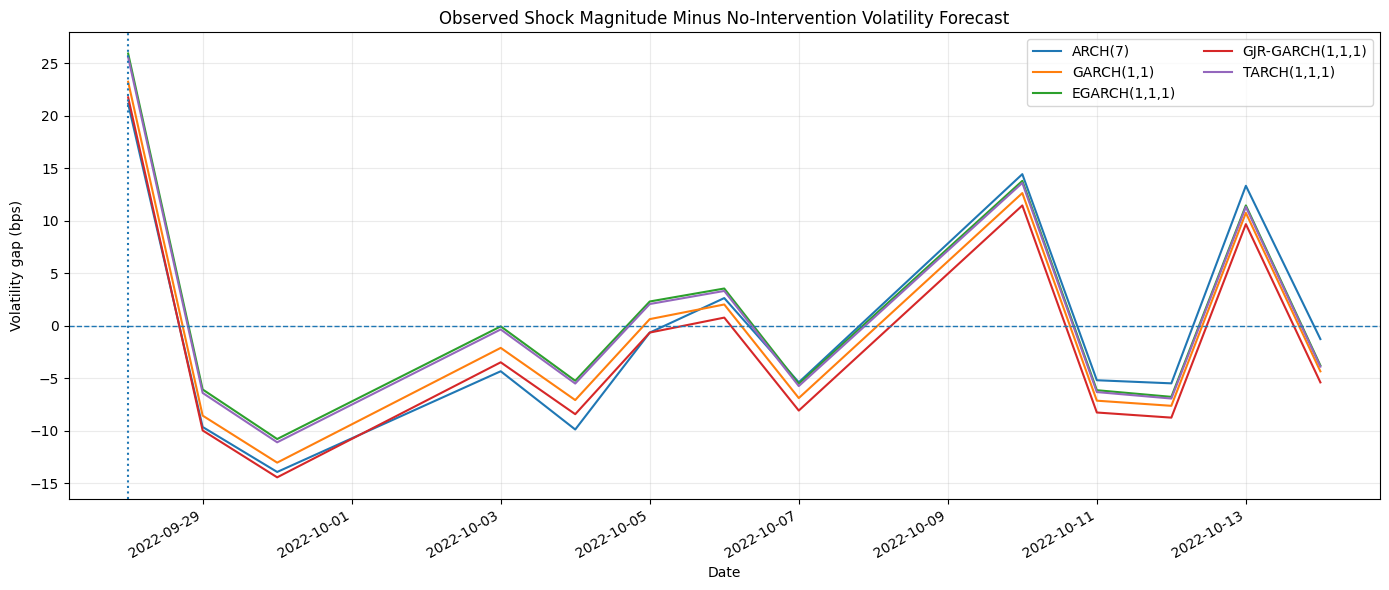

In [30]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

for name in (
    MODEL_SPECS.keys()
):

    ax.plot(
        volatility_gap_table["date"],
        volatility_gap_table[
            f"{name} gap (bps)"
        ],
        
        linewidth=1.5,
        label=name
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    INTERVENTION_DATE,
    linestyle=":",
    linewidth=1.5
)

ax.set_title(
    "Observed Shock Magnitude Minus No-Intervention Volatility Forecast"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Volatility gap (bps)"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    ncol=2
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

- The volatility gap is calculated as **realised absolute innovation minus the no-intervention volatility forecast**.
- A **positive gap** means the realised shock was larger than the model expected; a **negative gap** means it was smaller. The largest positive gap occurs on **28 September**, at roughly **21–26 bps** across models.
- Further large positive gaps appear on **10 October** and **13 October**, while most other days have negative gaps. The post-intervention period contains a few unusually large shocks rather than continuously elevated realised shock magnitude.

### Conclusion

Conditional volatility was already elevated by **27 September 2022**, indicating that substantial market stress was present before the Bank of England intervention. The fixed-origin no-intervention forecasts suggest that volatility would have remained elevated after 28 September but generally declined over the following weeks.

The realised shock on **28 September** was exceptionally large relative to all model-implied no-intervention volatility paths. Subsequent observations were mixed: several days were quieter than the counterfactual forecasts, while other dates, particularly around **10 and 13 October**, again produced unusually large shocks.

Overall, the post-intervention period does not show a simple immediate collapse in volatility. Instead, it remains characterised by alternating periods of relatively calm and large market shocks. These differences are **model-based counterfactual comparisons and should not be interpreted as causal estimates of the effect of the Bank of England intervention**.

In [32]:
OUTPUT_DIR = (
    Path("outputs")
    / "conditional_volatility_no_boe_intervention"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

arch_lm_results.to_csv(
    OUTPUT_DIR
    / "preintervention_arch_lm_tests.csv",
    index=False
)

arch_order_selection.to_csv(
    OUTPUT_DIR
    / "preintervention_arch_order_selection.csv",
    index=False
)

fit_comparison.to_csv(
    OUTPUT_DIR
    / "preintervention_model_fit_comparison.csv",
    index=False
)

parameter_table.to_csv(
    OUTPUT_DIR
    / "preintervention_model_parameters.csv",
    index=False
)

volatility_diagnostics.to_csv(
    OUTPUT_DIR
    / "preintervention_volatility_diagnostics.csv",
    index=False
)

no_intervention_table.to_csv(
    OUTPUT_DIR
    / "no_boe_intervention_volatility_counterfactual.csv",
    index=False
)

post_intervention_forecast_metrics.to_csv(
    OUTPUT_DIR
    / "no_boe_intervention_forecast_metrics.csv",
    index=False
)

standardized_innovation_table.to_csv(
    OUTPUT_DIR
    / "postintervention_standardized_innovations.csv",
    index=False
)

volatility_gap_table.to_csv(
    OUTPUT_DIR
    / "model_based_volatility_gaps.csv",
    index=False
)

print(
    "Saved outputs to:",
    OUTPUT_DIR.resolve()
)

Saved outputs to: /Users/qp252008/Downloads/Dissertation/outputs/conditional_volatility_no_boe_intervention
